
Before we construct the proper RAW model, we need to remember that typcially subcarrier spacings are **15kHz for LTE, 30/60kHz for Higher-Throughput and 60/120kHz for mmWave**, the decisive factor is bandwidth since it combines:
$$\text{Bandwidth} = \text{fft\_size} \times \text{subcarrier\_spacing}$$


There are 12 subcarriers in each PRB (Physical Resource Block), and 14 OFDM symbols in each  slot, and it is not related to `resourcegrid()` object that we need to utilize in our model


The research model we are trying to build is a basic Detnet with full Sionna PHY chain (OFDM, 5G LDPC, CDL channel Estimation and Equalization),
**Talker ---->hop1--->Relay (Base Station)--->hop2-->Listener**

Each hop is an independent OFDM link, that will be assigned with resource grid, CDL channel, encoder and decoder, and relay decodes hop 1, and only if it
decodes successully once it re-encode and forard to hop2, acting as a **DetNet's store and foward semantics.**

Since we utilize PHY layer, the deterministic schedular reserves fixed 2-slot cycle (slot 0 is Talker==>Relay, slot 1 is Relay==>Listener), this is the baseline of DetNet-style scheduling.

We will add redundancy and replication in the later stage

The simulation environment relies on *Sionna 2.0.1*


# 1. Import Libraries

In [1]:
import numpy as np
#Not sure we still need pytorch, but keep this thing in mind
import torch
from sionna.phy import Block
from sionna.phy.mapping import BinarySource, Mapper, Demapper
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers
from sionna.phy.mimo import StreamManagement
from sionna.phy.channel.tr38901 import CDL, Antenna
from sionna.phy.channel import OFDMChannel
from sionna.phy.utils import ebnodb2no, compute_ber
import matplotlib.pyplot as plt


# 2. Global Variables

Global Initiate Configuration: We are using 5G NR parameters here

In [2]:
CARRIER_FREQUENCY = 3.5e9 #Hz
SUBCARRIER_SPACING = 30e3 #Hz
FFT_SIZE = 76 #subcarriers
NUM_OFDM_SYMBOLS = 14 #One slot for OFDM symbols
NUM_BITS_PER_SYMBOL = 2 #QPSK
CODERATE = 0.5 #Not all part of symbol is information bits
CDL_MODEL = "C" #Mderate Delay Mode
DELAY_SPREAD = 100e-9 #s
UE_SPEED = 60.0 #m/s, cars
BATCH_SIZE = 64
EBN0_DB = 8.0 #Per-hop SNR, we can testify various options

##Latency Section
RELAY_PROCESSING_DELAY_S=50e-6
RELAY_QUEUE_SERVICE_RATE=2

#Burst
BURST_RNG_SEED=2026
BURST_BACKGROUND_SIZE=np.array([0, 1, 2, 3])
BURST_BACKGROUND_PROBS=np.array([0.75, 0.15, 0.03, 0.07])


#Timeout Mechanism---These two parameters affecting the results significantly
LATENCY_DEADLINE_S =2.0e-3
PACKET_TIMEOUT_S=9.0e-3


#ARQ Retries

MAX_RETRY_TIME_S=LATENCY_DEADLINE_S-RELAY_PROCESSING_DELAY_S





RESOURCE_GRID=ResourceGrid(
    num_ofdm_symbols=NUM_OFDM_SYMBOLS,
    fft_size=FFT_SIZE,
    subcarrier_spacing=SUBCARRIER_SPACING,
    num_tx=1,
    num_streams_per_tx=1,
    cyclic_prefix_length=6,
    pilot_pattern="kronecker",
    pilot_ofdm_symbol_indices=[2,11],
    
)

STREAM_MANAGEMENT = StreamManagement (np.array([[1]]),1)

N_CODED = int (RESOURCE_GRID.num_data_symbols * NUM_BITS_PER_SYMBOL)
K_INFO = int (N_CODED * CODERATE)


print (f"Information bits {K_INFO}, {N_CODED} coded bits per PDU")




Information bits 912, 1824 coded bits per PDU


# 3. Latency, ARQ, SimClock

**Measured Latency**
Although the latency in this stage remains identical since we do not addd any flunctuational factors to the transmitted PDU yet, but we utilize depature/arrival timestamps with a simulated clock to compute the realistic latency to build an evaluation based for a complex system later on.

We add timestamp to each PDU with a real depature time (leave the Talker) and arrival time (it is decoded at the listener), and compute the **latency as the difference of those two timestamps**, `SimClock` advances in real seconds, utilzing the actual OFDM slot duration derived from `OFDM Resource Grid` not from Python wall-clock since it refelects on hardware and overhead instead of physical link

The output latency should be identical in this version of development since we add one path with same initial PDU



In [3]:
class SimClock:
    """
    Tracking simulated elapsed time in real seconds, advancing by the
    actual OFDM slots duration each time a slot is consumed. The PDU depature
    and arrival times and measure latency as a real difference, the clock
    is continuously crossing the cycles not reset, therefore, it should reflect
    a single ongoing PDU timeline
    """
    def __init__(self, slot_duration_s):
        self.slot_duration_s=slot_duration_s
        self.t=0.0

    def now(self):
        return self.t
        
    def advance_slot(self):
        self.t += self.slot_duration_s
        return self.t


    #The slot duration is from OFDM numerology in Resource_Grid()
    #with cyclic prefix with same topology/channel
    #The measurement is implemented instead of asssumption



ofdm_symbol_duration = RESOURCE_GRID.ofdm_symbol_duration #seconds with CP
slot_duration_s=NUM_OFDM_SYMBOLS * ofdm_symbol_duration

print(f"OFDM Symbol Duration with Cyclic Prefix: {ofdm_symbol_duration*1e6:.3f} us")
print(f"Slot Duration: {slot_duration_s*1e6:.3f} us")
    
        

    

    

OFDM Symbol Duration with Cyclic Prefix: 35.965 us
Slot Duration: 503.509 us


In [4]:
###Queueing and Processing Delay & Latency Section

class RelayQueue:

    def __init__(self, service_rate_per_cycle=1):
        self.service_rate_per_cycle=service_rate_per_cycle
        self.backlog=0

    def queueing_delay_cycles_for_tagged_batch(self, background_batches=0):
        self.backlog+=background_batches
        queued_ahead=self.backlog
        self.backlog+=1

        return queued_ahead // self.service_rate_per_cycle


    def serve (self):
        served=min(self.backlog, self.service_rate_per_cycle)
        self.backlog -= served
        return served


def sample_background_burst(rng):
    return int(rng.choice(BURST_BACKGROUND_SIZE, p=BURST_BACKGROUND_PROBS))

def build_latency_metrics(end_to_end_ok, delivered_latency_s):
    delivered_latency_vector_s=np.full(end_to_end_ok.shape, np.nan)
    #Delivered_latency_s can be a scalar
    delivered_latency_broadcast_s=np.broadcast_to(delivered_latency_s, end_to_end_ok.shape)
    delivered_latency_vector_s[end_to_end_ok]=delivered_latency_broadcast_s[end_to_end_ok]


    completion_latency_s=np.where(
        end_to_end_ok,
        delivered_latency_s,
        PACKET_TIMEOUT_S
    )

    deadline_miss_rate=completion_latency_s>LATENCY_DEADLINE_S

    packet_loss_rate=~end_to_end_ok


    #SLA: Service Level Agreement is that RFC 9912 treats late packet a fault

    sla_compliant=end_to_end_ok & (completion_latency_s<=LATENCY_DEADLINE_S)

    return{

        "delivered_latency_s": delivered_latency_vector_s,
        "completion_latency_s": completion_latency_s,
        "p95_completion_latency_s": float(np.percentile(completion_latency_s, 95)),
        "p99_completion_latency_s": float(np.percentile(completion_latency_s, 99)),
        "worst_completion_latency_s": float(np.max(completion_latency_s)),
        "deadline_miss_rate": float(np.mean(deadline_miss_rate)),
        "packet_loss_rate": float(np.mean(packet_loss_rate)),
        "sla_compliant_rate": float(np.mean(sla_compliant)),
        
    }

    

In [5]:
#We start utilizing AQR now to reach the latency results we desire


def Retry_Group_Until_Success_Or_Budget(entries, clock, departure_time, max_retry_time_s):

    """
    entries: list of dict with keys including hop, bit, batch_size, ok
    Return a list of final_ok, attempts_used matching input order

    """

    oks=[e['ok'] for e in entries]
    attempts=[1]*len(entries)

    while not all(np.all(ok) for ok in oks):
        if clock.now()-departure_time+slot_duration_s>max_retry_time_s:
            break
        for i, e in enumerate(entries):
            if np.all(oks[i]):
                continue
            _, _, ok_retry=e['hop'](e['batch_size'], tx_bits=e['bits'])
            oks[i]=oks[i] | ok_retry
            attempts[i]+=1
        clock.advance_slot()
    return list(zip(oks, attempts))

# 4. DetNet, Redundant, PLR

Now, we start building *PHY Link* with one OFDM Hop

The workflow is: `Bits-->LDPC-->QAM-->OFDM ResourceGird-->CDL Channel-->LS Channel Estimation-->LMMSE Equalization-->Demap-->LDPC Decode`
In general, this is one single DetNet hop (Talker-->Relay or Relay-->Listener)

In [6]:
class PHYLINK (Block):
    def __init__(self, name, ebno_db=EBN0_DB):
        super().__init__()
        self.name=name
        self.ebno_db=ebno_db


        self.binary_source = BinarySource()
        self.encoder = LDPC5GEncoder(K_INFO, N_CODED)
        self.mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self.rg_mapper = ResourceGridMapper (RESOURCE_GRID)


        tx_antenna = Antenna(polarization="single",
                             polarization_type ="V",
                             antenna_pattern="38.901",
                             carrier_frequency=CARRIER_FREQUENCY)

        rx_antenna = Antenna(polarization="single",
                             polarization_type="V",
                            antenna_pattern="38.901",
                            carrier_frequency=CARRIER_FREQUENCY)

        self.cdl = CDL(model=CDL_MODEL,
                      delay_spread=DELAY_SPREAD,
                      carrier_frequency=CARRIER_FREQUENCY,
                      ut_array=rx_antenna,
                      bs_array=tx_antenna,
                      direction="uplink",
                      min_speed=UE_SPEED,
                      max_speed=UE_SPEED, #Tunable Parameter
                      )
        self.channel = OFDMChannel(self.cdl,
                                   RESOURCE_GRID,
                                   add_awgn=True,
                                   normalize_channel=True,
                                   return_channel=False,
            
        )

        self.ls_set = LSChannelEstimator(RESOURCE_GRID,interpolation_type="nn")
        self.lmmse_equ = LMMSEEqualizer(RESOURCE_GRID, STREAM_MANAGEMENT)
        self.demapper = Demapper("app","qam",NUM_BITS_PER_SYMBOL)
        self.decoder = LDPC5GDecoder(self.encoder, num_iter=20)



    def call(self, batch_size, tx_bits=None):    
            """
            Runs one PDU batch cross this hop.

            If there is no tx_bits, the function generates the fresh payload,
            else, the information bitsa are transmitted

            Return per_pdu_success is a boolean numpy vector of shape [batch_size]
            indicating the scheduler that PDUs crosss this hop successfully

            """

            if tx_bits is None:
                tx_bits = self.binary_source ([batch_size, 1,1,K_INFO])

            codewords = self.encoder(tx_bits)
            symbols = self.mapper(codewords)
            x_rg = self.rg_mapper(symbols)

            no = ebnodb2no(self.ebno_db, NUM_BITS_PER_SYMBOL,CODERATE, RESOURCE_GRID)
            y = self.channel (x_rg, no)

            h_hat, err_var = self.ls_set(y,no)
            x_hat, no_eff = self.lmmse_equ(y, h_hat, err_var, no)
        
            #We add a real-time link quality proxy, it works before decoding process
            # a real reciever know  this from channel estimation/equalization well before it knows whether PDU
            # will be decoded correctly, higher no_eff represents the worse link, and this is the TRIGGER for PLR
            #react within the SAME cycle instead of next one.

            #Low no_eff means the symbol is trustworthy and high value is the sign of noisy and reliable.


            self.last_no_eff = float(no_eff.mean().detach().cpu().item())
            #Mean compresses the tesnor into 0-dimension
            #Detach strips the gradient-tracking machinery off to avoid memory waste
            #cpu because python native float lives in CPU and we need to copy the original one from GPU
            #item extract that single value from tensor object to have a plain python scalar
            #self.last_no_eff stored the value so other part can see how noisy was channel for hop 1a on the recent call
            





        
            llr = self.demapper(x_hat, no_eff)
            decoded_bits = self.decoder(llr)

            #Per-PDU success: perfect match between sent and decoded inrfo bits
            #A CRC check on a real DetNet PDU


            matches=torch.all(
                torch.eq(tx_bits.to(torch.int32),decoded_bits.to(torch.int32)),
                dim = -1,
            )

            success = matches.reshape(-1).cpu().numpy()

            return tx_bits, decoded_bits, success

        

#CDL (Clustered Delay Line Channel Model) gives a realistic standardized multipath fading channel, so the link is experiencing some interference more than AWGN

#LS Estimator (Least Squares Channel Estimation) allows the receiver to estimated channel before equalization based on known pilot symbols to have reliable DetNet Link

#LMMSE Equalizer removies the distortion the channel has from the interfenece and fading, and receiver can recover symbol.

#CDL (creates a realistic, imperfect channel) 
#→ LS (estimates that unknown channel from pilots) 
#→ LMMSE (uses the estimate to undo channel distortion) 
#→ clean symbols → decoder → reliable bits.

        
        
        

**DetNet Scheduler: Fixed 2-Slot Cycle**

-slot 0: Talker-->Relay (Hop1)
-slot 1: Relay-->Listener (Hop2)

Calling `run_cycle()` each time to simulate one fixed-length cycyle for a batch of PDUs precisely, and to report if each PDU reaches to listener within the bouded latency (2 slots) or gets dropped


In [7]:
class DetNetScheduler:

    def __init__(self, batch_size=BATCH_SIZE, clock =None, rng=None):
        self.batch_size = batch_size
        self.hop1 = PHYLINK ("Talker->Relay")
        self.hop2 = PHYLINK ("Relay->Listener")
        self.clock=clock if clock is not None else SimClock(slot_duration_s)
        #latency section
        self.relay_queue=RelayQueue(RELAY_QUEUE_SERVICE_RATE)
        #burst
        self.rng=np.random.default_rng(BURST_RNG_SEED) if rng is None else rng
        

    def run_cycle(self):

        departure_time=self.clock.now()#The moment that PDU departs from Talker
        
        #Slot 0+ Per Hop ARQ retry, it is bounded by MAX_RETRY_TIME_S
        tx_bits, relay_rx_bits, hop1_ok = self.hop1 (self.batch_size)
        self.clock.advance_slot()

        #ARQ Detection
        hop1_ok, hop1_attempts=Retry_Group_Until_Success_Or_Budget(
            [{'hop': self.hop1, 'bits': tx_bits, 'batch_size':self.batch_size, 'ok': hop1_ok}],
            self.clock, departure_time, MAX_RETRY_TIME_S
            
        )[0]

        
        #latency section+Burst
        background_batches=sample_background_burst(self.rng)
        queue_delay_cycles=self.relay_queue.queueing_delay_cycles_for_tagged_batch(
            background_batches=background_batches
        )
        self.relay_queue.serve()
        
    

        #Slot 1 + Per Hop ARQ, same principle with slot 0
        
        _, listener_rx_bits, hop2_ok = self.hop2(self.batch_size, tx_bits=relay_rx_bits)
        arrival_time=self.clock.advance_slot()#PDU arrives at the Listener
        #ARQ Detection
        hop2_ok, hop2_attempts=Retry_Group_Until_Success_Or_Budget(
            [{'hop': self.hop2, 'bits': relay_rx_bits, 'batch_size': self.batch_size, 'ok': hop2_ok}],
            self.clock, departure_time, MAX_RETRY_TIME_S
        )[0]
        

        end_to_end_ok = hop1_ok & hop2_ok

        #Latency Section: we do some repairs here
        queue_delay_s=queue_delay_cycles*2*slot_duration_s
        processing_delay_s=RELAY_PROCESSING_DELAY_S
        raw_transit_time_s=arrival_time-departure_time+processing_delay_s+queue_delay_s
        latency_s=np.where(end_to_end_ok, raw_transit_time_s, PACKET_TIMEOUT_S)
        latency_metrics=build_latency_metrics(end_to_end_ok, latency_s)
        

        return {"hop1_success_rate":float(np.mean(hop1_ok)),
                "hop2_success_rate":float(np.mean(hop2_ok)),
                "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
                "end_to_end_ok":end_to_end_ok,
                "departure_time_s": departure_time,
                "arrival_time_s": arrival_time,
                "relay_processing_delay_s":processing_delay_s,
                "relay_queueing_delay_s": queue_delay_s,
                "relay_background_batches": background_batches,
                "hop1_retransmission": hop1_attempts-1,
                "hop2_rertansmission": hop2_attempts-1,
                "delivered_latency_s": latency_metrics["delivered_latency_s"],
                "completion_latency_s": latency_metrics["completion_latency_s"],
                "p95_completion_latency_s": latency_metrics["p95_completion_latency_s"],
                "p99_completion_latency_s": latency_metrics["p99_completion_latency_s"],
                "worst_completion_latency_s": latency_metrics["worst_completion_latency_s"],
                "deadline_miss_rate": latency_metrics["deadline_miss_rate"],
                "packet_loss_rate": latency_metrics["packet_loss_rate"],
                "sla_compliant_rate":latency_metrics["sla_compliant_rate"],
                "end_to_end_latency_s":float(np.mean(latency_s)),
                #"end_to_end_latency_slots": round(latency_s/slot_duration_s)
                
                
            
        }

**Step2: Rebundancy--RAW Path Replicatuon and Elimination Mechanism**

-The baseline from step 1 implemented a single path with no protection, if either hop drops the PDU, the transmission failed

-RAW intends to utilize **PAREO (Packet Replicate and Eliminiate)** to replicate the PDU across multiple disjoint paths, then eliminate duplicates at the receiver and accept the PDU if at least one path delivered it correctly.


The topology in step 2 should be:


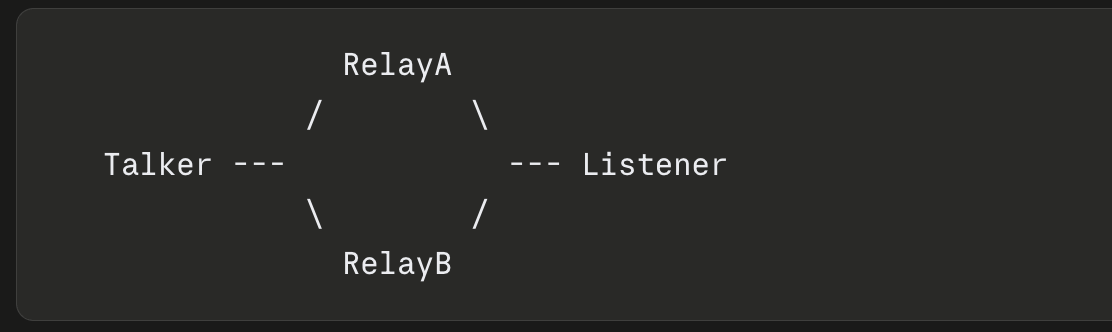


We also need to clearify End_to_End Success is PATH A or Path B, and the resource from Talker remians identical other than adding slots to emphasize the reduancy based on the baseline structure

In [8]:
class RedundantDetNetScheduler:
    """
    The redundancy form RAW is to replicate each PDU over two independent
    paths and remain fixed 2 slots cycle as the baseline has

    Path A: Talker-->Relay A-->Listener
    Path B: Talker-->Relay B--> Listner

    The success delivery is based on EITHER path has PDU arrived
    """

    def __init__(self, batch_size=BATCH_SIZE, ebno=EBN0_DB,clock=None, rng=None):
        self.batch_size = batch_size


        #Path A
        self.hop1a=PHYLINK("Talker-->RelayA")
        self.hop2a=PHYLINK("RelayA-->Listener")

        #Path B
        self.hop1b=PHYLINK("Talker-->RelayB")
        self.hop2b=PHYLINK("RelayB-->Listener")

        self.clock = clock if clock is not None else SimClock(slot_duration_s)

        #Latency section
        self.relay_queue_a=RelayQueue(RELAY_QUEUE_SERVICE_RATE)
        self.relay_queue_b=RelayQueue(RELAY_QUEUE_SERVICE_RATE)
        #burst
        self.rng=np.random.default_rng(BURST_RNG_SEED) if rng is None else rng
     


    def run_cycle(self):

        departure_time=self.clock.now()
        #Slot 0 Talker replicates two PDUs for both relays
        tx_bits, rxA1, okA1 = self.hop1a(self.batch_size)

        _, rxB1, okB1 = self.hop1b(self.batch_size, tx_bits=tx_bits)
        self.clock.advance_slot()

        #Per-hop ARQ mechanism, both paths should support it and they are bounded by MAX_RETRY_TIME_S, we repaired this part
        (okA1, attemptsA1), (okB1, attemptsB1)= Retry_Group_Until_Success_Or_Budget(
            [
                {'hop':self.hop1a, 'bits': tx_bits, 'batch_size': self.batch_size, 'ok':okA1},
                {'hop':self.hop1b, 'bits': tx_bits, 'batch_size': self.batch_size, 'ok':okB1},
            ], self.clock, departure_time, MAX_RETRY_TIME_S
        )


        #latency section+burst
        background_batches_a=sample_background_burst(self.rng)
        background_batches_b=sample_background_burst(self.rng)

        queue_delay_cycles_a=self.relay_queue_a.queueing_delay_cycles_for_tagged_batch(background_batches_a)
        queue_delay_cycles_b=self.relay_queue_b.queueing_delay_cycles_for_tagged_batch(background_batches_b)

        self.relay_queue_a.serve()
        self.relay_queue_b.serve()
        


        #Slot 1 Each relay fowards the received PDU (Store and Foward)
        _, rxA2, okA2 = self.hop2a(self.batch_size, tx_bits=rxA1)
        _, rxB2, okB2 = self.hop2b(self.batch_size, tx_bits=rxB1)

        arrival_time=self.clock.advance_slot()



        #Per Hop ARQ machanism
        (okA2, attemptsA2), (okB2, attemptsB2)= Retry_Group_Until_Success_Or_Budget(
            [
                {'hop': self.hop2a, 'bits':rxA1, 'batch_size': self.batch_size, 'ok': okA2},
                {'hop': self.hop2b, 'bits':rxB1, 'batch_size': self.batch_size, 'ok': okB2},
            ], self.clock, departure_time, MAX_RETRY_TIME_S
        )
        arrival_time=self.clock.now()#Retries should have advanced it further
        


        path_a_ok = okA1 & okA2
        path_b_ok = okB1 & okB2

        #Elimination: the reciever should only accept the pdu if either path
        end_to_end_ok = path_a_ok | path_b_ok

        
        
        #Latency Section, we repair this part after the large repair
        processing_delay_s=RELAY_PROCESSING_DELAY_S
        #repair
        path_a_slots=attemptsA1+attemptsA2
        path_b_slots=attemptsB1+attemptsB2
        latency_a_s=path_a_slots*slot_duration_s+processing_delay_s+queue_delay_cycles_a*2*slot_duration_s
        latency_b_s=path_b_slots*slot_duration_s+processing_delay_s+queue_delay_cycles_b*2*slot_duration_s

        latency_s=np.where(
            path_a_ok & path_b_ok, np.minimum(latency_a_s, latency_b_s),
            np.where(path_a_ok, latency_a_s,
                    np.where(path_b_ok, latency_b_s,PACKET_TIMEOUT_S))
        )

        queue_delay_selected_s=np.where(
            path_a_ok & path_b_ok, np.minimum(queue_delay_cycles_a, queue_delay_cycles_b)*2*slot_duration_s,
            np.where(path_a_ok, queue_delay_cycles_a*2*slot_duration_s,
                    np.where(path_b_ok, queue_delay_cycles_b*2*slot_duration_s, np.nan))
            
        )

        latency_metrics=build_latency_metrics(end_to_end_ok, latency_s)
       

        return {
            "path_a_success_rate": float(np.mean(path_a_ok)),
            "path_b_success_rate": float(np.mean(path_b_ok)),
            "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
            "end_to_end_ok": end_to_end_ok,
            "departure_time_s":departure_time,
            "arriveal_time_s":arrival_time,
            "relay_processing_delay_s": processing_delay_s,
            "relay_queueing_delay_s": float(np.nanmean(queue_delay_selected_s)),
            "relay_background_batches_a": background_batches_a,
            "relay_background_batches_b": background_batches_b,
            "path_a_retransmission": (attemptsA1-1)+(attemptsA2-1),
            "path_b_retransmission": (attemptsB1-1)+(attemptsB2-1),
            "delivered_latency_s": latency_metrics["delivered_latency_s"],
            "completion_latency_s": latency_metrics["completion_latency_s"],
            "p95_completion_latency_s": latency_metrics["p95_completion_latency_s"],
            "p99_completion_latency_s": latency_metrics["p99_completion_latency_s"],
            "worst_completion_latency_s": latency_metrics["worst_completion_latency_s"],
            "deadline_miss_rate": latency_metrics["deadline_miss_rate"],
            "packet_loss_rate": latency_metrics["packet_loss_rate"],
            "sla_compliant_rate": latency_metrics["sla_compliant_rate"],
            "end_to_end_latency_s":float(np.mean(latency_s)),
            #"end_to_end_latency": round(latency_s/slot_duration_s)
            
        }
        
        
        

**Point of Local Repair**: the next stage, we want to have a control loop that engages the protection path only when it needs, and the trigger factors can be link degradation, and we can have an efficient topology closing to RAW model.

###React within the same cycle

A post-hoc scheme is not suitable for industrial operation since it must implement the core mechanism one full cycle late, the solution is to have a physical proxy that is available before decoding but after that process.

We have added a stored self.last_no_eff section, and we need to implement the new `LinkQualityMonitor` to have a **Point of Local Repair**

The following section is **only the process of constructing `LinkQualityMonitor`, `PLRscheduler`, and a simple simulation recycle**, we will compare these models later on.



In [9]:
class LinkQualityMonitor:
    """
    Tracking the link-quality in real time for mitigation process.
    If high no_eff displays, it represents the low link qualition, and the countermeasure should be engaged
    """

    def __init__(self, alpha=0.5, engage_no_eff=None, disengage_no_eff=None):
        if disengage_no_eff is not None and engage_no_eff is not None and disengage_no_eff >= engage_no_eff:
            raise ValueError("disengage_no_eff must be lower than engage_no_eff because higher no_eff means worse link quality")
        self.alpha = alpha
        self.engage_no_eff=engage_no_eff
        self.disengage_no_eff=disengage_no_eff
        self.ewma_no_eff=None
        self.backup_engaged=False

    def decide (self, current_no_eff):
        """
        Called during the mid-cycle, right after hop1A's channel estimation is available.
        Udpating the EWMA with this cycle's reading and returning the engage decision for the SAME cycyle.
        
        """
        if self.ewma_no_eff is None:
            self.ewma_no_eff = current_no_eff #The initial observation, there is no historical record yet
        else:
            self.ewma_no_eff = self.alpha*current_no_eff+(1-self.alpha)*self.ewma_no_eff


        #Bugrepair:the decision of engag/disengage should react to the smoothed self.ewma_no_eff
        #Not the current_no_eff, otherwise EWMA is computed but does not apply to any cycles
            
        if not self.backup_engaged and self.ewma_no_eff >= self.engage_no_eff:
            self.backup_engaged=True
        elif self.backup_engaged and self.ewma_no_eff <= self.disengage_no_eff:
            self.backup_engaged=False
        return self.backup_engaged
            

    

In [23]:
class PLRScheduler:
    """
    Point of Local Repair: Relay B only transmits when the LinkQualityMonitor
    detects degradation on Relay A within its real-time channel quality (no_eff)
    that affects on decision and action within the same cycle before PDU is decoded
    from Relay A.
    """

    def __init__(self, batch_size=BATCH_SIZE, clock=None, monitor=None, rng=None):
        self.batch_size=batch_size

        self.hop1a=PHYLINK("Talker-->RelayA")
        self.hop2a=PHYLINK("RelayA-->Listener")
        self.hop1b=PHYLINK("Talker-->RelayB")
        self.hop2b=PHYLINK("RelayB-->Listener")


        self.clock=clock if clock is not None else SimClock(slot_duration_s)
        self.monitor=monitor#Required: passing a calibrated LinkQualityMonitor

        #Latency Section
        self.relay_queue_a=RelayQueue(RELAY_QUEUE_SERVICE_RATE)
        self.relay_queue_b=RelayQueue(RELAY_QUEUE_SERVICE_RATE)
        #burst
        self.rng=np.random.default_rng(BURST_RNG_SEED) if rng is None else rng

        
        


    def run_cycle(self, ebno_override=None):
        if ebno_override is not None:
            self.hop1a.ebno_db=ebno_override
            self.hop2a.ebno_db=ebno_override

        departure_time=self.clock.now()

        #Slot 0 part 1: Primary path transmits and its channel is estimated
        tx_bits, rxA1, okA1=self.hop1a(self.batch_size)

        #Real-tim decision for the same cycle, no_eff rading is available now before hop2a decodes
        engage_backup=self.monitor.decide(self.hop1a.last_no_eff)
        

        #Slot 0 part 2: only transmitted if the monitor engaged backup
        if engage_backup:
            _,rxB1, okB1=self.hop1b(self.batch_size,tx_bits=tx_bits)
        self.clock.advance_slot()

        #Per-Hop ARQ Mechanism
        if engage_backup:
            (okA1, attemptsA1),(okB1, attemptsB1)=Retry_Group_Until_Success_Or_Budget(
                [
                    {'hop': self.hop1a, 'bits': tx_bits, 'batch_size': self.batch_size, 'ok': okA1},
                    {'hop': self.hop1b, 'bits': tx_bits, 'batch_size': self.batch_size, 'ok': okB1},
                
                ], self.clock, departure_time, MAX_RETRY_TIME_S
            )
        else:
            okA1, attemptsA1=Retry_Group_Until_Success_Or_Budget(
                [{'hop': self.hop1a, 'bits': tx_bits, 'batch_size': self.batch_size, 'ok': okA1}],
                self.clock, departure_time, MAX_RETRY_TIME_S
            )[0]

        

        #Latency Section+burst

        background_batches_a=sample_background_burst(self.rng)
        queue_delay_cycles_a=self.relay_queue_a.queueing_delay_cycles_for_tagged_batch(background_batches_a)
        self.relay_queue_a.serve()

        if engage_backup:
            background_batches_b=sample_background_burst(self.rng)
            queue_delay_cycles_b=self.relay_queue_b.queueing_delay_cycles_for_tagged_batch(background_batches_b)
            self.relay_queue_b.serve()

        else:
            background_batches_b=0
            queue_delay_cycles_b=0
       


        #Slot 1
        _, rxA2, okA2 = self.hop2a(self.batch_size, tx_bits=rxA1)
        
        if engage_backup:
            _, rxB2, okB2 = self.hop2b(self.batch_size, tx_bits=rxB1) #Redunadncy tirgger

        arrival_time=self.clock.advance_slot()

        path_a_ok=okA1 & okA2

        #Per-hop ARQ Mechanism

        if engage_backup:
            (okA2, attemptsA2), (okB2, attemptsB2)= Retry_Group_Until_Success_Or_Budget(
                [
                    {'hop': self.hop2a, 'bits': rxA1, 'batch_size': self.batch_size, 'ok': okA2},
                    {'hop': self.hop2b, 'bits': rxB1, 'batch_size': self.batch_size, 'ok': okB2},
                ], self.clock, departure_time, MAX_RETRY_TIME_S
            )

        else:
            (okA2, attemptsA2)=Retry_Group_Until_Success_Or_Budget(
                [{'hop': self.hop2a, 'bits': rxA1, 'batch_size': self.batch_size, 'ok': okA2}],
                self.clock, departure_time, MAX_RETRY_TIME_S
            )[0]

        arrival_time=self.clock.now()#Retries can have advanced the clock
        path_a_ok=okA1 & okA2


        if engage_backup:
            path_b_ok = okB1 & okB2
            end_to_end_ok = path_a_ok | path_b_ok
            path_b_success_rate=float(np.mean(path_b_ok))
        else:
            end_to_end_ok=path_a_ok
            path_b_success_rate=None


            
        #Latency Section, we tried to repair this one after seeding measurment

        processing_delay_s=RELAY_PROCESSING_DELAY_S
        #Repair
        path_a_slots=attemptsA1+attemptsA2
        latency_a_s=path_a_slots*slot_duration_s+processing_delay_s+queue_delay_cycles_a*2*slot_duration_s
        
        

        if engage_backup:
            #Second place we did the repair
            path_b_slots=attemptsB1+attemptsB2
            latency_b_s=path_b_slots*slot_duration_s+processing_delay_s+queue_delay_cycles_b*2*slot_duration_s
            latency_s=np.where(
                path_a_ok & path_b_ok, np.minimum(latency_a_s, latency_b_s),
                np.where(path_a_ok, latency_a_s,
                        np.where(path_b_ok, latency_b_s, PACKET_TIMEOUT_S))
            )
            queue_delay_selected_s=np.where(

                path_a_ok & path_b_ok, np.minimum(queue_delay_cycles_a, queue_delay_cycles_b)*2*slot_duration_s,
                np.where(path_a_ok, queue_delay_cycles_a*2*slot_duration_s,
                        np.where(path_b_ok, queue_delay_cycles_b*2*slot_duration_s, np.nan))
            )


            
        else:
            #Backup will not be transmitted this cycle if path A is stable
            latency_s=np.where(path_a_ok, latency_a_s, PACKET_TIMEOUT_S)
            queue_delay_selected_s=queue_delay_cycles_a*2*slot_duration_s


        latency_metrics=build_latency_metrics(end_to_end_ok, latency_s)
        
  
        
        
          

        return {
            "backup_engaged": engage_backup,
            "no_eff": self.hop1a.last_no_eff,
            "path_a_success_rate": float(np.mean(path_a_ok)),
            "path_b_success_rate": path_b_success_rate,
            "end_to_end_success_rate": float(np.mean(end_to_end_ok)),
            "end_to_end_ok": end_to_end_ok,#It should be MCL
            "departure_time_s":departure_time,
            "arrival_time_s": arrival_time,
            "relay_processing_delay_s": processing_delay_s,
            "relay_queueing_delay_s": float(np.nanmean(queue_delay_selected_s)),
            "relay_background_batches_a": background_batches_a,
            "relay_background_batches_b": background_batches_b,
            "path_a_retransmissions": (attemptsA1-1)+(attemptsA2-1),
            "path_b_retransmissions":(attemptsB1-1)+(attemptsB2-1) if engage_backup else None, #we consider path B as well now
            "delivered_latency_s": latency_metrics["delivered_latency_s"],
            "completion_latency_s": latency_metrics["completion_latency_s"],
            "p95_completion_latency_s": latency_metrics["p95_completion_latency_s"],
            "p99_completion_latency_s": latency_metrics["p99_completion_latency_s"],
            "worst_completion_latency_s": latency_metrics["worst_completion_latency_s"],
            "deadline_miss_rate": latency_metrics["deadline_miss_rate"],
            "packet_loss_rate": latency_metrics["packet_loss_rate"],
            "sla_compliant_rate": latency_metrics["sla_compliant_rate"],
            "end_to_end_latency_s":float(np.mean(latency_s)),
            #"end_to_end_latency_slots": round(latency_s/slot_duration_s),
        
        }
            
        
        

        
    

# 5. RAW Control Layer

## Plane Separarion

We have a fundamental blueprint at this point, but we must separate two primary planes based on the specifications on RFC8655, RFC9912, and RFC9913

The current `PLRScheduler` mixes two operations with one method whose decision on `backup_engage` and executing PHY transmissions altogether, we must split the decisive and transportation mechanism to match the RAW requirements based on DetNet architecture, yet it is more feasible to scale up the relay and BS nodes in the later stage.

The way of resolving it is to add a `RAWController` class, which should not have `PHYLINK` objects and does not transmit the data, it only needs to map `LinkQuality` reading to an active-path decision. The regression ensures that it reproduces PLRScheduler's own decisions, and utilize `no_eff` value from plr_results without adding new PHY simulation.

In [11]:
class RAWController:
    """
    Control plane: it must justify WHICH path should be active for this cycle
    based on the link quality (no_eff). It should not have PHY objects and does
    not transmit anything.

    """

    def __init__(self, monitors):
        """
        monitors: direct mapping a link to a calibrated LinkQualityMonitor
        that is responsible for that link.
        
        """
        self.monitors=monitors


    def select_paths(self, quality_readings):
        """
        quality_readings: direct mapping to link name--> this cycle's no_eff value
        for whichever links reported one

        return a dictionary of path activation decisions
        """
        decisions={"path_a": True}#The default path should be active initially

        engage_backup=False
        for link_name, reading in quality_readings.items():
            if link_name in self.monitors:
                if self.monitors[link_name].decide(reading):
                    engage_backup=True
                    
        decisions["path_b"]=engage_backup
        return decisions

        

**Regression Inspect**: before anything can utilize RAWController, confirming that it should reproduce `PLRScheduler ` with its engage and disengage exactly, by using the same no_eff values and same calibrated thresholds, stage 2 should not be considered if it does not match.

In [12]:
def ebno_for_cycle(cycle, nominal_ebno=EBN0_DB, fade_start=8, fade_end=13, fade_penalty=5.0):
    """
    Test hareness: simulating path A with Talker-->Relay A link degrading fro cycles [fade_start, fade_end],
    then recoevering. A realistic system would get this signal from measured link quality not a scripted schedule

    """
    if fade_start<=cycle<=fade_end:
        return nominal_ebno-fade_penalty

    else:
        return nominal_ebno


In [13]:
torch.manual_seed(1)

#The value here should depend on the calibration cell with its no_eff

monitor=LinkQualityMonitor(alpha=0.7, engage_no_eff=1.05, disengage_no_eff=1.0)
plr_scheduler=PLRScheduler(batch_size=BATCH_SIZE, monitor=monitor)


num_cycles=5  #trimmed from 20 -- this is a decision-matching check, not a statistical one, so a small sample is equally valid and far cheaper
plr_results=[]

for cycle in range (num_cycles):
    ebno_this_cycle=ebno_for_cycle(cycle)
    stats=plr_scheduler.run_cycle(ebno_override=ebno_this_cycle)
    plr_results.append(stats)


    backup_str="ENGAGED" if stats["backup_engaged"] else "idle"
    pB=f"{stats['path_b_success_rate']*100:5.1f}% " if stats["path_b_success_rate"] is not None else "n/a"
    print(f"cycle{cycle:2d} | ebno:{ebno_this_cycle:4.1f} dB |no_eff:{stats['no_eff']:.6f}"
         f" | backup:{backup_str}"
         f" | pathA: {stats['path_a_success_rate']*100:5.1f}% |path B:{pB}"
         f" | end_to_end: {stats['end_to_end_success_rate']*100:5.1f}%"
         f" | latency: {stats['end_to_end_latency_s']*1e3:4f}ms")

    engaged_fraction=np.mean([s['backup_engaged'] for s in plr_results])
    print(f"\n Backup path engaged in {engaged_fraction*100:.1f}% of cycles"
         f"(vs. 100% for always-on redundancy link).")

    

cycle 0 | ebno: 8.0 dB |no_eff:0.628918 | backup:idle | pathA: 100.0% |path B:n/a | end_to_end: 100.0% | latency: 1.560526ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 1 | ebno: 8.0 dB |no_eff:1.068699 | backup:idle | pathA: 100.0% |path B:n/a | end_to_end: 100.0% | latency: 1.560526ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 2 | ebno: 8.0 dB |no_eff:0.920744 | backup:idle | pathA: 100.0% |path B:n/a | end_to_end: 100.0% | latency: 1.057018ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 3 | ebno: 8.0 dB |no_eff:0.623863 | backup:idle | pathA:  95.3% |path B:n/a | end_to_end:  95.3% | latency: 1.909252ms

 Backup path engaged in 0.0% of cycles(vs. 100% for always-on redundancy link).
cycle 4 | ebno: 8.0 dB |no_eff:0.660993 | backup:idle | pathA: 100.0% |path B:n/a | end_to_end: 100.0% | latency: 1.560526ms

 Backup path engaged in 0.0% of cycles(vs. 100% fo

In [14]:
check_monitor=LinkQualityMonitor(alpha=0.5, engage_no_eff=2.5, disengage_no_eff=1.5)
controller = RAWController(monitors={"hop1a":check_monitor})

mismatches=0
for cycle, stats in enumerate(plr_results):
    decision=controller.select_paths({"hop1a":stats["no_eff"]})
    if decision["path_b"]!= stats["backup_engaged"]:
        mismatches+=1
        print(f"Mismatch happens at cycle: {cycle}: controller={decision['path_b']}, scheduler={stats['backup_engaged']}")
    if mismatches==0:
        print(f"RAWController is producing the same decision as PLRScheduler for all {len(plr_results)} cycles.")
    else:
        print(f"{mismatches} mismatches founded, not good !")

RAWController is producing the same decision as PLRScheduler for all 5 cycles.
RAWController is producing the same decision as PLRScheduler for all 5 cycles.
RAWController is producing the same decision as PLRScheduler for all 5 cycles.
RAWController is producing the same decision as PLRScheduler for all 5 cycles.
RAWController is producing the same decision as PLRScheduler for all 5 cycles.


# 6. Raw Data Layer

## Randomized Faded Scenario Generator

We start utilzing new methodology to produce a more fluctuating channel condition, because `ebno_for_cycle()` is utilzing fixed fade, and we create a function that generates various randomized scenarios, and we can have a more valuable measurement and convincing results

In [15]:
def Generate_Fade_Scenario(rng, nominal_ebno=EBN0_DB, num_cycles=20,
                          fade_duration_range=(3,8), fade_penalty_range=(2.0, 6.0)):

    """
    The fade scenario has been randomized: a random start cycle,
    duration, and severity (dB penalty), we set the range based on
    the calibiration.

    We utilize a caller-supplied numpy generator to have reproducible
    results based on given seed.

    Returning Per-Cycle EBN0 list plus the scenario's paramters
    
    """

    fade_duration=int(rng.integers(fade_duration_range[0], fade_duration_range[1]+1))
    latest_start=max(num_cycles - fade_duration, 1)
    fade_start=int(rng.integers(0, latest_start))
    fade_penalty=float(rng.uniform(fade_penalty_range[0],fade_penalty_range[1]))

    ebno_schedule=[]
    for cycle in range(num_cycles):
        if fade_start <= cycle < fade_start+fade_duration:
            ebno_schedule.append(nominal_ebno-fade_penalty)
        else:
            ebno_schedule.append(nominal_ebno)
    scenario_info={
        "fade_start": fade_start,
        "fade_duration": fade_duration,
        "fade_penalty": fade_penalty,
        
        
    }

    return ebno_schedule, scenario_info

#Function Check: generating a group of scenarios

rng=np.random.default_rng(seed=42)
for trial in range (5):
    schedule, info=Generate_Fade_Scenario(rng)
    print(f"trial {trial}: start (cycle)={info['fade_start']:2d}, "
          f"duration (cycles)={info['fade_duration']}, "
          f"penalty={info['fade_penalty']:.2f} dB"
         )

trial 0: start (cycle)=13, duration (cycles)=3, penalty=3.76 dB
trial 1: start (cycle)=12, duration (cycles)=5, penalty=4.79 dB
trial 2: start (cycle)= 1, duration (cycles)=4, penalty=5.90 dB
trial 3: start (cycle)= 9, duration (cycles)=7, penalty=5.14 dB
trial 4: start (cycle)= 1, duration (cycles)=6, penalty=3.80 dB


## Consistent Configuration Comparison: Baseline, Redundant, and PLR

We have created a section to generate the random fade based on defined range, now we need to ensure all schedulers have the same scenarios, same seed, and same ebno because we want to have a *fair* comparison and measurments.



In [16]:
rng=np.random.default_rng(seed=123)
scenario_ebno, scenario_info=Generate_Fade_Scenario(rng, nominal_ebno=EBN0_DB, num_cycles=20)
print(f"Scenario: fade starts at cycle {scenario_info['fade_start']}, "
     f"duration for={scenario_info['fade_duration']} cycles, "
     f"penality={scenario_info['fade_penalty']:.2f} dB\n")

torch.manual_seed(1)

baseline_scheduler_m=DetNetScheduler(batch_size=BATCH_SIZE, rng=np.random.default_rng(BURST_RNG_SEED))
redundant_scheduler_m=RedundantDetNetScheduler(batch_size=BATCH_SIZE,rng=np.random.default_rng(BURST_RNG_SEED))
plr_monitor_m=LinkQualityMonitor(alpha=0.8, engage_no_eff=1.05, disengage_no_eff=1.00)

#When we increased alpha, the one single degraded cycle closes most of the gap than 0.5
#
#
#
#
plr_scheduler_m=PLRScheduler(batch_size=BATCH_SIZE, monitor=plr_monitor_m, rng=np.random.default_rng(BURST_RNG_SEED))

num_cycles=len(scenario_ebno)
baseline_results_m=[]
redundant_results_m=[]
plr_results_m=[]

for cycle in range(num_cycles):
    ebno_this_cycle=scenario_ebno[cycle]

    #Baseline
    baseline_scheduler_m.hop1.ebno_db=ebno_this_cycle
    baseline_scheduler_m.hop2.ebno_db=ebno_this_cycle
    b_stats=baseline_scheduler_m.run_cycle()
    baseline_results_m.append(b_stats)

    #Always On Redundant
    redundant_scheduler_m.hop1a.ebno_db=ebno_this_cycle
    redundant_scheduler_m.hop2a.ebno_db=ebno_this_cycle
    r_stats=redundant_scheduler_m.run_cycle()
    redundant_results_m.append(r_stats)
    
    
    #Point Local Repair
    p_stats=plr_scheduler_m.run_cycle(ebno_override=ebno_this_cycle)
    plr_results_m.append(p_stats)

    # print(f"cycle: {cycle:2d} | ebno: {ebno_this_cycle:4.1f} dB "
    #      f"| Basline: {b_stats['end_to_end_success_rate']*100:5.1f}% "
    #      f"| Redundant: {r_stats['end_to_end_success_rate']*100:5.1f}% "
    #      f"| PLR: {p_stats['end_to_end_success_rate']*100:5.1f}% "
    #      f"| no_eff: {p_stats['no_eff']:.4f} "
    #       f"| latency: {p_stats['end_to_end_latency_s']*1e3:.4f} ms "
    #       f"| queuedelay: {p_stats['relay_queueing_delay_s']*1e3:.4f} ms "
    #       f"| p99 completion Baseline/Redundant/PLR: "
    #       f"{b_stats['p99_completion_latency_s']*1e3:.4f}/"
    #       f"{r_stats['p99_completion_latency_s']*1e3:.4f}/"
    #       f"{p_stats['p99_completion_latency_s']*1e3:.4f} ms"
    #       f"| miss rate Basline/Reundant/PLR: "
    #       f"{b_stats['deadline_miss_rate']*100:.1f}%/"
    #       f"{r_stats['deadline_miss_rate']*100:.1f}%/"
    #       f"{p_stats['deadline_miss_rate']*100:.1f}%"
    #       f"| packet loss rate Basline/Redundant/PLR: "
    #       f"{b_stats['packet_loss_rate']*100:.1f}%/"
    #       f"{r_stats['packet_loss_rate']*100:.1f}%/"
    #       f"{p_stats['packet_loss_rate']*100:.1f}%"
    #       f"(backup {'ON' if p_stats['backup_engaged'] else 'OFF'})"
    #      )
    # print()


    print(f"cycle: {cycle:2d} | ebno: {ebno_this_cycle:4.1f} dB "
         f"| Basline: {b_stats['end_to_end_success_rate']*100:5.1f}% "
         f"| Redundant: {r_stats['end_to_end_success_rate']*100:5.1f}% "
         f"| PLR: {p_stats['end_to_end_success_rate']*100:5.1f}% "
         f"| no_eff: {p_stats['no_eff']:.4f} "
          f"| Baseline-latency: {b_stats['end_to_end_latency_s']*1e3:.4f} ms "
          f"| Redundant-latency: {r_stats['end_to_end_latency_s']*1e3:.4f} ms "
          f"| PLR-latency:  {p_stats['end_to_end_latency_s']*1e3:.4f} ms"
          f"| queuedelay: {p_stats['relay_queueing_delay_s']*1e3:.4f} ms"
          f"(backup {'ON' if p_stats['backup_engaged'] else 'OFF'})"
         )
    print()


Scenario: fade starts at cycle 11, duration for=3 cycles, penality=2.22 dB

cycle:  0 | ebno:  8.0 dB | Basline: 100.0% | Redundant: 100.0% | PLR:  95.3% | no_eff: 0.8175 | Baseline-latency: 1.0570 ms | Redundant-latency: 1.0570 ms | PLR-latency:  1.9093 ms| queuedelay: 0.0000 ms(backup OFF)

cycle:  1 | ebno:  8.0 dB | Basline:  96.9% | Redundant: 100.0% | PLR: 100.0% | no_eff: 0.6485 | Baseline-latency: 1.7930 ms | Redundant-latency: 1.0570 ms | PLR-latency:  1.5605 ms| queuedelay: 0.0000 ms(backup OFF)

cycle:  2 | ebno:  8.0 dB | Basline: 100.0% | Redundant: 100.0% | PLR: 100.0% | no_eff: 0.7511 | Baseline-latency: 1.5605 ms | Redundant-latency: 1.0570 ms | PLR-latency:  1.5605 ms| queuedelay: 0.0000 ms(backup OFF)

cycle:  3 | ebno:  8.0 dB | Basline: 100.0% | Redundant: 100.0% | PLR: 100.0% | no_eff: 0.6885 | Baseline-latency: 1.0570 ms | Redundant-latency: 1.0806 ms | PLR-latency:  1.5605 ms| queuedelay: 0.0000 ms(backup OFF)

cycle:  4 | ebno:  8.0 dB | Basline:  98.4% | Redund

# 7. Measurement Configuration

###Calibration


We must calibrate the **threshold** firstly because `no_eff` nomral values depend on the EBN0/CDL/Coderate configuration, we run few cycles at normal EBN0 and another few ones with degraded EBN0 to check the variation of *no_eff*  abased on both rigmes, then we need to set `engage_no_eff/disengage_eff` betwen those ranges.

In [17]:
#Calibration:observing no_eff at nominal and degraded EBN0 before selecting the thresholds
#Enhanced: we need to observe no_eff at nominal EBN0, and full fade_penalty_range used by Generated_Fade_Scenario
#other than just a hardcoded 5dB because it can cause inactive status if the random fade does not reach the threshold


N_CALIBRATION_PROBES=30
probe_link=PHYLINK("calibration probe")


def Mean_No_Eff(ebno_db, n=N_CALIBRATION_PROBES):

    vals=[]
    probe_link.ebno_db=ebno_db
    for _ in range(n):
        _=probe_link(BATCH_SIZE)
        vals.append(probe_link.last_no_eff)
    return float(np.mean(vals)), float(np.std(vals))


nominal_mean, nominal_std=Mean_No_Eff(EBN0_DB)

print(f"no_eff at nominal EBNO ({EBN0_DB} dB): mean={nominal_mean:.4f}, std={nominal_std:.4f} (n={N_CALIBRATION_PROBES})")
print()

print("no_eff acrosss the ACTUAL fade_penalty_range used by Generate_Fade_Scenario (2-6dB):")
for penalty in [2.0, 3.0, 4.0, 5.0, 6.0]:
    m, s=Mean_No_Eff(EBN0_DB - penalty)
    gap=m-nominal_mean
    print(f" penalty={penalty:.1f} dB | mean={m:4f}, std={s:.4f} | gap over nominal={gap:+.4f}")

print()
print("We are using the SMALLEST penalty to detect the backup mechanism")





no_eff at nominal EBNO (8.0 dB): mean=0.9545, std=0.8736 (n=30)

no_eff acrosss the ACTUAL fade_penalty_range used by Generate_Fade_Scenario (2-6dB):
 penalty=2.0 dB | mean=1.747016, std=0.6519 | gap over nominal=+0.7925
 penalty=3.0 dB | mean=2.713921, std=0.9019 | gap over nominal=+1.7594
 penalty=4.0 dB | mean=7.414048, std=9.9914 | gap over nominal=+6.4595
 penalty=5.0 dB | mean=5.454554, std=1.7490 | gap over nominal=+4.5001
 penalty=6.0 dB | mean=8.337405, std=5.3510 | gap over nominal=+7.3829

We are using the SMALLEST penalty to detect the backup mechanism


### Time-budgeted multi-seed sweep

You're running this on a laptop (M5 MacBook), not a cluster, so the seed
count below is **not hardcoded** -- it's derived from a live timing probe
so the sweep fits inside a wall-clock budget instead of guessing and
either wasting your afternoon or leaving time on the table.

Two things keep per-seed cost down without weakening the statistical
test: `SWEEP_BATCH_SIZE` is smaller than the main `BATCH_SIZE` (32 vs 64)
-- statistical power here comes from **many independent seeds**, not a
big batch each seed, so halving the batch roughly doubles how many seeds
fit in the same time; and only Baseline and PLR are run (Redundant is
not needed for the baseline-vs-PLR significance test).


In [18]:
import time

SWEEP_TIME_BUDGET_S = 15*60   #keep the sweep itself under 90 min, leaving buffer under your 2-hour cap
SWEEP_BATCH_SIZE = 32          #smaller than BATCH_SIZE -- statistical power here comes from many
                                #independent seeds, not a big batch each seed
SWEEP_NUM_CYCLES = 40
MIN_SWEEP_SEEDS = 5
MAX_SWEEP_SEEDS = 200          #safety ceiling in case the timing probe is unexpectedly fast

def run_one_seed(seed, batch_size=SWEEP_BATCH_SIZE, num_cycles=SWEEP_NUM_CYCLES):
    """
    One full Baseline + Redundant + PLR run under an independently drawn
    fade scenario -- the actual three-way comparison, not a subset.
    Returns per-cycle results for all three, plus the scenario's fade
    window (as a set of cycle indices) so nominal-vs-fade cycles can be
    split out downstream.
    """
    rng=np.random.default_rng(seed=seed)
    scenario_ebno, scenario_info=Generate_Fade_Scenario(rng, nominal_ebno=EBN0_DB, num_cycles=num_cycles)
    torch.manual_seed(seed)

    baseline_scheduler=DetNetScheduler(batch_size=batch_size, rng=np.random.default_rng(seed*1000+1))
    redundant_scheduler=RedundantDetNetScheduler(batch_size=batch_size, rng=np.random.default_rng(seed*1000+2))
    monitor=LinkQualityMonitor(alpha=0.8, engage_no_eff=1.05, disengage_no_eff=1.00)
    plr_scheduler=PLRScheduler(batch_size=batch_size, monitor=monitor, rng=np.random.default_rng(seed*1000+3))

    baseline_results=[]
    redundant_results=[]
    plr_results=[]
    for cycle in range(num_cycles):
        ebno_this_cycle=scenario_ebno[cycle]

        baseline_scheduler.hop1.ebno_db=ebno_this_cycle
        baseline_scheduler.hop2.ebno_db=ebno_this_cycle
        baseline_results.append(baseline_scheduler.run_cycle())

        redundant_scheduler.hop1a.ebno_db=ebno_this_cycle
        redundant_scheduler.hop2a.ebno_db=ebno_this_cycle
        redundant_results.append(redundant_scheduler.run_cycle())

        plr_results.append(plr_scheduler.run_cycle(ebno_override=ebno_this_cycle))

    fade_start=scenario_info["fade_start"]
    fade_cycles=set(range(fade_start, fade_start+scenario_info["fade_duration"]))
    return baseline_results, redundant_results, plr_results, fade_cycles, scenario_info


#--- Timing probe: measure ONE seed's real cost (now with 3 schedulers,
#not 2) before committing to a seed count. ---
_probe_start=time.time()
_ = run_one_seed(seed=999999)  #seed far outside the real sweep range, so it never collides
_probe_elapsed_s=time.time()-_probe_start

_max_seeds_by_time=int(SWEEP_TIME_BUDGET_S // _probe_elapsed_s) if _probe_elapsed_s > 0 else MAX_SWEEP_SEEDS
N_SWEEP_SEEDS=max(MIN_SWEEP_SEEDS, min(MAX_SWEEP_SEEDS, _max_seeds_by_time))

print(f"One seed (Baseline+Redundant+PLR) took {_probe_elapsed_s:.1f}s at batch_size={SWEEP_BATCH_SIZE}, {SWEEP_NUM_CYCLES} cycles.")
print(f"Budget={SWEEP_TIME_BUDGET_S/60:.0f} min -> N_SWEEP_SEEDS={N_SWEEP_SEEDS} "
      f"(estimated total ~{N_SWEEP_SEEDS*_probe_elapsed_s/60:.1f} min).")
print("If this estimate looks too high for your afternoon, lower SWEEP_TIME_BUDGET_S above and re-run this cell.")


One seed (Baseline+Redundant+PLR) took 41.7s at batch_size=32, 40 cycles.
Budget=15 min -> N_SWEEP_SEEDS=21 (estimated total ~14.6 min).
If this estimate looks too high for your afternoon, lower SWEEP_TIME_BUDGET_S above and re-run this cell.


# 8. Measurements

In [19]:
#Fade window condition metrics
#This section breaks PDR/Packet Loss/Deadline Miss Rate for "during" vs
#"outside" of the fade window, since PLR's payoff is concentrated in the
#fade window and gets diluted by whole-run averages otherwise.

fade_start=scenario_info["fade_start"]
fade_end=fade_start+scenario_info["fade_duration"]
fade_cycles=set(range(fade_start, fade_end))

def _windowed_metrics(results, fade_cycles):
    in_fade=[r for i, r in enumerate(results) if i in fade_cycles]
    out_fade=[r for i, r in enumerate(results) if i not in fade_cycles]

    def _avg(rs, key):
        return float(np.mean([r[key] for r in rs])) if rs else float("nan")
    return {
        "pdr_in_fade": _avg(in_fade, "end_to_end_success_rate"),
        "pdr_out_fade": _avg(out_fade, "end_to_end_success_rate"),
        "loss_in_fade": _avg(in_fade, "packet_loss_rate"),
        "loss_out_fade": _avg(out_fade, "packet_loss_rate"),
        "miss_in_fade": _avg(in_fade, "deadline_miss_rate"),
        "miss_out_fade": _avg(out_fade, "deadline_miss_rate"),
    }

schemes={
    "Baseline": baseline_results_m,
    "Redundant": redundant_results_m,
    "PLR": plr_results_m,
}

print(f"Fade window: cycles {fade_start}-{fade_end-1} "
      f"({scenario_info['fade_duration']} cycles, "
      f"penalty {scenario_info['fade_penalty']:.2f} dB)\n")

print(f"{'scheme':<10} | {'PDR in-fade':>12} | {'PDR out-fade':>13} | "
      f"{'loss in-fade':>12} | {'loss out-fade':>13} | "
      f"{'miss in-fade':>12} | {'miss out-fade':>13}")

for name, results in schemes.items():
    m=_windowed_metrics(results, fade_cycles)
    print(f"{name:<10} | {m['pdr_in_fade']*100:11.2f}% | {m['pdr_out_fade']*100:12.2f}% | "
          f"{m['loss_in_fade']*100:11.2f}% | {m['loss_out_fade']*100:12.2f}% | "
          f"{m['miss_in_fade']*100:11.2f}% | {m['miss_out_fade']*100:12.2f}%")

#How much of the fade window PLR actually reacted to
plr_engaged_in_fade=np.mean([plr_results_m[i]["backup_engaged"] for i in fade_cycles])
plr_engaged_out_fade=np.mean([plr_results_m[i]["backup_engaged"] for i in range(len(plr_results_m)) if i not in fade_cycles])
print(f"\nPLR backup engaged: {plr_engaged_in_fade*100:.1f}% of in-fade cycles, "
      f"{plr_engaged_out_fade*100:.1f}% of out-of-fade cycles.")
print("If engaged-in-fade is low, the monitor is not detecting the fade -- "
      "recheck engage_no_eff/disengage_no_eff against the calibration cell's output.")


Fade window: cycles 11-13 (3 cycles, penalty 2.22 dB)

scheme     |  PDR in-fade |  PDR out-fade | loss in-fade | loss out-fade | miss in-fade | miss out-fade
Baseline   |       60.94% |        98.62% |       39.06% |         1.38% |      100.00% |        24.26%
Redundant  |      100.00% |       100.00% |        0.00% |         0.00% |        0.52% |        12.13%
PLR        |       99.48% |        99.08% |        0.52% |         0.92% |        0.52% |        18.47%

PLR backup engaged: 100.0% of in-fade cycles, 5.9% of out-of-fade cycles.
If engaged-in-fade is low, the monitor is not detecting the fade -- recheck engage_no_eff/disengage_no_eff against the calibration cell's output.


In [20]:
#The latency we have defined by far is conflated with various delay since we want to create an analysis with separation

def Pooled_Delivered_Latency_Stats(results, cycles=None):

    if cycles is None:
        pooled=np.concatenate([r["delivered_latency_s"] for r in results])
        loss=float(np.mean([r["packet_loss_rate"] for r in results]))

    else:
        pooled=np.concatenate([r["delivered_latency_s"] for i, r in enumerate(results) if i in cycles])
        loss=float(np.mean([r["packet_loss_rate"] for i, r in enumerate(results) if i in cycles]))
    delivered=pooled[~np.isnan(pooled)]


    return {

        "n_delivered": int(delivered.size),
        "n_total": int(pooled.size),
        "packet_loss_rate": loss,
        "p50_latency_s": float(np.percentile(delivered, 50)) if delivered.size else float("nan"),
        "p95_latency_s": float(np.percentile(delivered, 95)) if delivered.size else float("nan"),
        "p99_latency_s": float(np.percentile(delivered, 99)) if delivered.size else float("nan"),
        "worst_latency_s": float(np.max(delivered)) if delivered.size else float("nan"),
        
    }


schemes_for_latency={
    "Baseline:": baseline_results_m,
    "Redundant": redundant_results_m,
    "PLR": plr_results_m,
}

print("Delivered-only latency, pooled over full run:")
for name, results in schemes_for_latency.items():
    s=Pooled_Delivered_Latency_Stats(results)
    print(f"{name:<10} n={s['n_delivered']:4d}/{s['n_total']:<4d} | loss={s['packet_loss_rate']*100:5.1f}% | "
         f"p50={s['p50_latency_s']*1e3:.4f} ms | p95={s['p95_latency_s']*1e3:.4f} ms | "
         f"p99={s['p99_latency_s']*1e3:.4f} ms | worst={s['worst_latency_s']*1e3:.4f} ms")

print("\n Delivered-only latency, pooled over fade window only:")

for name, results in schemes_for_latency.items():
    s=Pooled_Delivered_Latency_Stats(results, cycles=fade_cycles)
    print(f"{name:<10} n={s['n_delivered']:4d}/{s['n_total']:<4d} | loss={s['packet_loss_rate']*100:5.1f}% | "
         f"p50={s['p50_latency_s']*1e3:.4f} ms | p95={s['p95_latency_s']*1e3:4f} ms | "
         f"p99={s['p99_latency_s']*1e3:.4f} ms | worst={s['worst_latency_s']*1e3:4f} ms")

Delivered-only latency, pooled over full run:
Baseline:  n=1190/1280 | loss=  7.0% | p50=1.5605 ms | p95=3.0711 ms | p99=4.0781 ms | worst=4.0781 ms
Redundant  n=1280/1280 | loss=  0.0% | p50=1.5605 ms | p95=2.5675 ms | p99=2.5675 ms | worst=2.5675 ms
PLR        n=1269/1280 | loss=  0.9% | p50=1.5605 ms | p95=2.5675 ms | p99=2.5675 ms | worst=2.5675 ms

 Delivered-only latency, pooled over fade window only:
Baseline:  n= 117/192  | loss= 39.1% | p50=3.0711 ms | p95=4.078070 ms | p99=4.0781 ms | worst=4.078070 ms
Redundant  n= 192/192  | loss=  0.0% | p50=1.5605 ms | p95=1.560526 ms | p99=1.5605 ms | worst=2.064035 ms
PLR        n= 191/192  | loss=  0.5% | p50=1.5605 ms | p95=1.560526 ms | p99=1.5605 ms | worst=1.560526 ms


In [21]:
def Max_Consecutive_Loss(ok_matrix):

    """
    ok_matrix: shape[num_cycles, batch_size], bool. Each column is one
    independent PDU stream observed over num_cycles time step, Returning
    the MCL per stream.
    """

    num_cycles, batch_size = ok_matrix.shape
    mcl_per_stream = np.zeros(batch_size, dtype=int)

    for b in range (batch_size):
        run = 0
        max_run=0
        for c in range (num_cycles):
            if not ok_matrix[c,b]:
                run+=1
                max_run=max(max_run, run)
            else:
                run = 0
        mcl_per_stream[b]=max_run
    return mcl_per_stream


### Running the sweep

A live wall-clock safety net is included below in case the timing probe
underestimated per-seed cost -- it stops early rather than blowing
through the budget, and prints partial results either way.


In [24]:
sweep_start=time.time()

schemes = ["Baseline", "Redundant", "PLR"]

#Raw per-PDU CSV: every single delivery outcome, written incrementally
#as the sweep runs rather than held in memory -- at full scale (many
#seeds x 20 cycles x SWEEP_BATCH_SIZE PDUs x 3 schemes) this is tens of
#thousands of rows, and building that as Python objects before writing
#risks memory pressure on a laptop. This is the true "every sample" CSV
#-- no aggregation, no compression, one row per PDU per cycle.
import csv as _csv
_raw_csv_path="sweep_results_all_samples.csv"
_raw_csv_file=open(_raw_csv_path, "w", newline="")
_raw_fieldnames=["seed_index","scheme","cycle_index","in_fade","pdu_index",
                  "end_to_end_ok","completion_latency_s_ms","delivered_latency_s_ms",
                  "fade_penalty_db","fade_duration_cycles",
                  "cycle_retransmissions_path_a","cycle_retransmissions_path_b",
                  "backup_engaged","cycle_queue_delay_ms"]
_raw_csv_writer=_csv.DictWriter(_raw_csv_file, fieldnames=_raw_fieldnames)
_raw_csv_writer.writeheader()
_raw_rows_written=0

#Outside-fade PDR: pooled successes/total per scheme, for the pairwise
#significance tests below
out_fade_successes={s:0 for s in schemes}
out_fade_total={s:0 for s in schemes}
in_fade_successes={s:0 for s in schemes}
in_fade_total={s:0 for s in schemes}

#Per-seed PDR, both outside AND inside the fade window (the in-fade one
#is new -- needed to check whether the aggregate in-fade PDR is being
#driven by fade severity, not just averaged blindly)
per_seed_pdr={s:[] for s in schemes}
per_seed_pdr_infade={s:[] for s in schemes}

#Per-seed fade severity/duration, aligned index-for-index with
#per_seed_pdr_infade, so severity can be plotted against PDR directly
per_seed_fade_penalty=[]
per_seed_fade_duration=[]

#Delivered-latency samples pooled across seeds, split full-run-outside-
#fade vs in-fade -- same treatment as the single-seed
#Pooled_Delivered_Latency_Stats, just aggregated across many independent
#seeds instead of one
pooled_delivered_latency={s:[] for s in schemes}
pooled_delivered_latency_infade={s:[] for s in schemes}

#Per-seed latency (delivered-only), both windows -- p50/p95/p99, not
#just p95, so the granular CSV export has the full percentile picture
#per seed, not just an aggregate.
per_seed_latency_p50={s:[] for s in schemes}
per_seed_latency_p95={s:[] for s in schemes}
per_seed_latency_p99={s:[] for s in schemes}
per_seed_latency_p50_infade={s:[] for s in schemes}
per_seed_latency_p95_infade={s:[] for s in schemes}
per_seed_latency_p99_infade={s:[] for s in schemes}

#Per-seed mean retransmissions -- field names differ by scheme
#(Baseline: hop1/hop2, Redundant/PLR: path_a/path_b), handled explicitly
#below rather than assuming a common key.
per_seed_mean_retransmissions={s:[] for s in schemes}

#Per-seed MCL, so we can report the TRUE worst-case (max across seeds),
#not a single-run number
per_seed_mcl={s:[] for s in schemes}

seeds_completed=0
for seed in range(N_SWEEP_SEEDS):
    elapsed=time.time()-sweep_start
    if elapsed > SWEEP_TIME_BUDGET_S:
        print(f"Stopping early at seed {seed} ({elapsed/60:.1f} min elapsed) -- time budget reached.")
        break

    baseline_results, redundant_results, plr_results, fade_cycles, scenario_info = run_one_seed(seed)
    results_by_scheme = {"Baseline": baseline_results, "Redundant": redundant_results, "PLR": plr_results}

    per_seed_fade_penalty.append(scenario_info["fade_penalty"])
    per_seed_fade_duration.append(scenario_info["fade_duration"])

    for name, results in results_by_scheme.items():
        seed_succ=0; seed_total=0
        seed_succ_infade=0; seed_total_infade=0
        seed_latency_samples=[]
        seed_latency_samples_infade=[]

        for i, r in enumerate(results):
            n=len(r["end_to_end_ok"])
            if i not in fade_cycles:
                seed_succ += int(np.sum(r["end_to_end_ok"]))
                seed_total += n
                pooled_delivered_latency[name].append(r["delivered_latency_s"])
                seed_latency_samples.append(r["delivered_latency_s"])
            else:
                seed_succ_infade += int(np.sum(r["end_to_end_ok"]))
                seed_total_infade += n
                pooled_delivered_latency_infade[name].append(r["delivered_latency_s"])
                seed_latency_samples_infade.append(r["delivered_latency_s"])

        in_fade_successes[name] += seed_succ_infade
        in_fade_total[name] += seed_total_infade

        out_fade_successes[name] += seed_succ
        out_fade_total[name] += seed_total
        if seed_total > 0:
            per_seed_pdr[name].append(seed_succ/seed_total)
        if seed_total_infade > 0:
            per_seed_pdr_infade[name].append(seed_succ_infade/seed_total_infade)
        else:
            per_seed_pdr_infade[name].append(float("nan"))  #scenario had no fade cycles at all, shouldn't happen but guard anyway

        pooled_seed_latency=np.concatenate(seed_latency_samples) if seed_latency_samples else np.array([])
        delivered_seed_latency=pooled_seed_latency[~np.isnan(pooled_seed_latency)]
        for p, store in [(50,per_seed_latency_p50),(95,per_seed_latency_p95),(99,per_seed_latency_p99)]:
            store[name].append(np.percentile(delivered_seed_latency,p) if delivered_seed_latency.size else float("nan"))

        pooled_seed_latency_infade=np.concatenate(seed_latency_samples_infade) if seed_latency_samples_infade else np.array([])
        delivered_seed_latency_infade=pooled_seed_latency_infade[~np.isnan(pooled_seed_latency_infade)]
        for p, store in [(50,per_seed_latency_p50_infade),(95,per_seed_latency_p95_infade),(99,per_seed_latency_p99_infade)]:
            store[name].append(np.percentile(delivered_seed_latency_infade,p) if delivered_seed_latency_infade.size else float("nan"))

        ok_matrix=np.stack([r["end_to_end_ok"] for r in results])
        mcl=Max_Consecutive_Loss(ok_matrix)
        per_seed_mcl[name].append(int(mcl.max()))

        #Retransmissions -- tracked SEPARATELY per path for every scheme
        #now, so Redundant and PLR are genuinely comparable (previously
        #Redundant summed path_a+path_b into one number while PLR only
        #counted path_a, making PLR look artificially cheaper). Baseline
        #has only one path (hop1+hop2 in sequence, not parallel), so its
        #"path_a" is that path's total and it has no path_b.
        #backup_engaged is also tracked per cycle for every scheme:
        #Baseline never has a second path (False), Redundant always
        #transmits both (True), PLR only when its monitor decides to (the
        #actual per-cycle decision) -- this lets the next sweep directly
        #test whether PLR's speed advantage concentrates in backup-off
        #cycles (running lean, single-path) or holds even when engaged.
        if name == "Baseline":
            retx_a=[r["hop1_retransmission"]+r["hop2_rertansmission"] for r in results]
            retx_b=[None]*len(results)
            backup_flags=[False]*len(results)
        elif name == "Redundant":
            retx_a=[r["path_a_retransmission"] for r in results]
            retx_b=[r["path_b_retransmission"] for r in results]
            backup_flags=[True]*len(results)
        else:  # PLR
            retx_a=[r["path_a_retransmissions"] for r in results]
            retx_b=[r["path_b_retransmissions"] for r in results]  #None on backup-off cycles
            backup_flags=[r["backup_engaged"] for r in results]
        per_seed_mean_retransmissions[name].append(float(np.mean(retx_a)))  #path_a only now -- comparable across ALL three schemes

        #--- Raw per-PDU rows: every single sample, no aggregation ---
        for cycle_idx, r in enumerate(results):
            n=len(r["end_to_end_ok"])
            for pdu_idx in range(n):
                delivered=r["delivered_latency_s"][pdu_idx]
                _raw_csv_writer.writerow({
                    "seed_index": seed,
                    "scheme": name,
                    "cycle_index": cycle_idx,
                    "in_fade": cycle_idx in fade_cycles,
                    "pdu_index": pdu_idx,
                    "end_to_end_ok": bool(r["end_to_end_ok"][pdu_idx]),
                    "completion_latency_s_ms": r["completion_latency_s"][pdu_idx]*1e3,
                    "delivered_latency_s_ms": (delivered*1e3) if not np.isnan(delivered) else "",
                    "fade_penalty_db": scenario_info["fade_penalty"],
                    "fade_duration_cycles": scenario_info["fade_duration"],
                    "cycle_retransmissions_path_a": retx_a[cycle_idx],
                    "cycle_retransmissions_path_b": retx_b[cycle_idx] if retx_b[cycle_idx] is not None else "",
                    "backup_engaged": backup_flags[cycle_idx],
                    "cycle_queue_delay_ms": r["relay_queueing_delay_s"]*1e3,
                })
                _raw_rows_written += 1

    seeds_completed += 1
    progress_step=max(1, N_SWEEP_SEEDS//10)
    if (seed+1) % progress_step == 0:
        print(f"  seed {seed+1}/{N_SWEEP_SEEDS} done ({(time.time()-sweep_start)/60:.1f} min elapsed)")

_raw_csv_file.close()
print(f"\nWrote {_raw_csv_path}: {_raw_rows_written} rows (every individual PDU outcome, no aggregation)")
print(f"Completed {seeds_completed} seeds in {(time.time()-sweep_start)/60:.1f} min.")


#--- Pairwise two-proportion z-tests: outside-fade PDR, now WITH the
#raw effect size (percentage-point gap) printed alongside the p-value.
#With n in the tens of thousands, even a trivial gap reaches p<0.05 --
#the effect size is what tells you whether that's a meaningful finding
#or just statistical power from a large sample. Implemented with just
#math.erf (standard library) -- no scipy dependency. ---
import math

def two_proportion_z_test(successes1, n1, successes2, n2):
    p1=successes1/n1
    p2=successes2/n2
    p_pool=(successes1+successes2)/(n1+n2)
    se=math.sqrt(p_pool*(1-p_pool)*(1/n1+1/n2))
    if se == 0:
        return p1, p2, float("nan"), float("nan")
    z=(p1-p2)/se
    p_value=2*(1-0.5*(1+math.erf(abs(z)/math.sqrt(2))))
    return p1, p2, z, p_value

print(f"\nOutside-fade PDR, pooled across {seeds_completed} seeds:")
for name in schemes:
    p=out_fade_successes[name]/out_fade_total[name]
    print(f"  {name:<10}: {p*100:.4f}% (n={out_fade_total[name]})")

print("\nPairwise significance (outside fade), with effect size:")
pairwise_pdr_results={}
for a, b in [("Baseline","Redundant"), ("Baseline","PLR"), ("Redundant","PLR")]:
    p1, p2, z, p_value = two_proportion_z_test(
        out_fade_successes[a], out_fade_total[a],
        out_fade_successes[b], out_fade_total[b]
    )
    pairwise_pdr_results[(a,b)]=(z,p_value,p1,p2)
    sig="significant" if p_value < 0.05 else "NOT significant"
    gap_pp=abs(p1-p2)*100
    print(f"  {a} vs {b}: z={z:.4f}, p={p_value:.4f} -> {sig} at alpha=0.05 "
          f"| effect size = {gap_pp:.4f} percentage points")


#--- Latency percentiles, pooled across seeds, delivered-only (no
#timeout sentinel mixed in). ---
print(f"\nDelivered-only latency, pooled across {seeds_completed} seeds (outside fade):")
for name in schemes:
    pooled=np.concatenate(pooled_delivered_latency[name]) if pooled_delivered_latency[name] else np.array([])
    delivered=pooled[~np.isnan(pooled)]
    if delivered.size:
        print(f"  {name:<10}: n={delivered.size:6d} | p50={np.percentile(delivered,50)*1e3:.4f} ms | "
              f"p95={np.percentile(delivered,95)*1e3:.4f} ms | p99={np.percentile(delivered,99)*1e3:.4f} ms")
    else:
        print(f"  {name:<10}: no delivered samples")

print(f"\nDelivered-only latency, pooled across {seeds_completed} seeds (in fade window):")
for name in schemes:
    pooled=np.concatenate(pooled_delivered_latency_infade[name]) if pooled_delivered_latency_infade[name] else np.array([])
    delivered=pooled[~np.isnan(pooled)]
    if delivered.size:
        print(f"  {name:<10}: n={delivered.size:6d} | p50={np.percentile(delivered,50)*1e3:.4f} ms | "
              f"p95={np.percentile(delivered,95)*1e3:.4f} ms | p99={np.percentile(delivered,99)*1e3:.4f} ms")
    else:
        print(f"  {name:<10}: no delivered samples")


#--- MCL: TRUE worst-case across seeds (max of per-seed max), not a
#single-run number. ---
print(f"\nWorst-case MCL across {seeds_completed} seeds:")
for name in schemes:
    mcls=per_seed_mcl[name]
    print(f"  {name:<10}: worst-case (max over seeds)={max(mcls)} | mean over seeds={np.mean(mcls):.2f}")


#--- Severity check: is the aggregate in-fade PDR being driven by a
#wide range of fade severities, rather than reflecting one typical case?
#Correlation between per-seed fade penalty and per-seed in-fade PDR,
#per scheme -- a strong negative correlation for Baseline (harsher fade
#-> lower PDR) would confirm the aggregate number reflects real
#severity variation, not an anomaly. ---
print(f"\nFade severity across {seeds_completed} seeds: "
      f"penalty range [{min(per_seed_fade_penalty):.2f}, {max(per_seed_fade_penalty):.2f}] dB, "
      f"duration range [{min(per_seed_fade_duration)}, {max(per_seed_fade_duration)}] cycles")
print("Correlation between fade penalty and in-fade PDR, per scheme:")
for name in schemes:
    pdrs=np.array(per_seed_pdr_infade[name])
    penalties=np.array(per_seed_fade_penalty)
    valid=~np.isnan(pdrs)
    if valid.sum() > 1:
        corr=np.corrcoef(penalties[valid], pdrs[valid])[0,1]
        print(f"  {name:<10}: corr(penalty, in-fade PDR) = {corr:.4f}")

  seed 2/21 done (1.2 min elapsed)
  seed 4/21 done (2.4 min elapsed)
  seed 6/21 done (3.7 min elapsed)
  seed 8/21 done (4.9 min elapsed)
  seed 10/21 done (6.1 min elapsed)
  seed 12/21 done (7.3 min elapsed)
  seed 14/21 done (8.6 min elapsed)
  seed 16/21 done (9.8 min elapsed)
  seed 18/21 done (11.1 min elapsed)
  seed 20/21 done (12.4 min elapsed)

Wrote sweep_results_all_samples.csv: 80640 rows (every individual PDU outcome, no aggregation)
Completed 21 seeds in 13.0 min.

Outside-fade PDR, pooled across 21 seeds:
  Baseline  : 99.4399% (n=22496)
  Redundant : 99.9778% (n=22496)
  PLR       : 99.3821% (n=22496)

Pairwise significance (outside fade), with effect size:
  Baseline vs Redundant: z=-10.5872, p=0.0000 -> significant at alpha=0.05 | effect size = 0.5379 percentage points
  Baseline vs PLR: z=0.8009, p=0.4232 -> NOT significant at alpha=0.05 | effect size = 0.0578 percentage points
  Redundant vs PLR: z=11.1846, p=0.0000 -> significant at alpha=0.05 | effect size = 0.

# 9. Plotting the Results


In [28]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

CSV_PATH = "sweep_results_all_samples.csv"

rows = []
with open(CSV_PATH, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        row["seed_index"] = int(row["seed_index"])
        row["cycle_index"] = int(row["cycle_index"])
        row["pdu_index"] = int(row["pdu_index"])
        row["in_fade"] = row["in_fade"] == "True"
        row["end_to_end_ok"] = row["end_to_end_ok"] == "True"
        row["backup_engaged"] = row["backup_engaged"] == "True"
        row["delivered_latency_s_ms"] = float(row["delivered_latency_s_ms"]) if row["delivered_latency_s_ms"] != "" else None
        rows.append(row)
print(f"Loaded {len(rows)} raw samples from {CSV_PATH}")

schemes = ["Baseline", "Redundant", "PLR"]

def worst_case_mcl(sub_rows):
    by_seed = defaultdict(list)
    for r in sub_rows:
        by_seed[r["seed_index"]].append(r)
    worst_per_seed = []
    for seed_idx, seed_rows in by_seed.items():
        by_pdu = defaultdict(dict)
        for r in seed_rows:
            by_pdu[r["pdu_index"]][r["cycle_index"]] = r["end_to_end_ok"]
        max_run_this_seed = 0
        for pdu_idx, cyc_map in by_pdu.items():
            run = 0
            for cyc in sorted(cyc_map.keys()):
                if not cyc_map[cyc]:
                    run += 1
                    max_run_this_seed = max(max_run_this_seed, run)
                else:
                    run = 0
        worst_per_seed.append(max_run_this_seed)
    return worst_per_seed

def analyze_and_plot(backup_filter):
    if backup_filter == "engaged":
        filtered = [r for r in rows if r["backup_engaged"]]
    elif backup_filter == "disengaged":
        filtered = [r for r in rows if not r["backup_engaged"]]
    else:
        filtered = rows

    print(f"Backup filter = '{backup_filter}' -> {len(filtered)} samples remain")
    print("(Baseline never engages backup, Redundant always does -- 'engaged'/"
          "'disengaged' will show no bar for whichever scheme's strategy is fixed)\n")

    stats = {}
    for window_name, want_infade in [("outside", False), ("infade", True)]:
        window_rows = [r for r in filtered if r["in_fade"] == want_infade]
        for scheme in schemes:
            sub = [r for r in window_rows if r["scheme"] == scheme]
            if not sub:
                stats[(scheme, window_name)] = None
                continue
            delivered = [r["delivered_latency_s_ms"] for r in sub if r["delivered_latency_s_ms"] is not None]
            pdr = sum(r["end_to_end_ok"] for r in sub) / len(sub) * 100
            if delivered:
                p50, p95, p99 = np.percentile(np.array(delivered), [50, 95, 99])
            else:
                p50 = p95 = p99 = np.nan
            stats[(scheme, window_name)] = dict(pdr=pdr, n=len(sub), delivered=len(delivered), p50=p50, p95=p95, p99=p99)

    for window_name in ["outside", "infade"]:
        print(f"=== {'OUTSIDE FADE' if window_name=='outside' else 'IN FADE'} (backup_filter={backup_filter}) ===")
        for scheme in schemes:
            s = stats[(scheme, window_name)]
            if s is None:
                print(f"  {scheme:<10}: no data under this filter")
            else:
                print(f"  {scheme:<10}: PDR={s['pdr']:6.2f}% (n={s['n']:6d}, delivered={s['delivered']:6d}) | "
                      f"p50={s['p50']:.4f} ms | p95={s['p95']:.4f} ms | p99={s['p99']:.4f} ms")
        print()

    infade_full = [r for r in rows if r["in_fade"]]
    mcl_stats = {}
    for scheme in schemes:
        sub = [r for r in infade_full if r["scheme"] == scheme]
        worst_per_seed = worst_case_mcl(sub)
        mcl_stats[scheme] = dict(worst=max(worst_per_seed), mean=np.mean(worst_per_seed))
    print("=== MCL (in-fade, full unbroken cycle sequence -- not affected by the backup toggle) ===")
    for scheme in schemes:
        m = mcl_stats[scheme]
        print(f"  {scheme:<10}: worst-case = {m['worst']} | mean = {m['mean']:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
    x = np.arange(len(schemes))
    width = 0.35

    pdr_outside = [stats[(s,"outside")]["pdr"] if stats[(s,"outside")] else 0 for s in schemes]
    pdr_infade = [stats[(s,"infade")]["pdr"] if stats[(s,"infade")] else 0 for s in schemes]
    axes[0].bar(x-width/2, pdr_outside, width, label="outside fade")
    axes[0].bar(x+width/2, pdr_infade, width, label="in fade")
    axes[0].set_xticks(x); axes[0].set_xticklabels(schemes)
    axes[0].set_ylabel("PDR (%)")
    axes[0].set_title(f"PDR (backup_filter={backup_filter})")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3, axis="y")

    p50s = [stats[(s,"infade")]["p50"] if stats[(s,"infade")] else np.nan for s in schemes]
    p95s = [stats[(s,"infade")]["p95"] if stats[(s,"infade")] else np.nan for s in schemes]
    p99s = [stats[(s,"infade")]["p99"] if stats[(s,"infade")] else np.nan for s in schemes]
    width2 = 0.25
    axes[1].bar(x-width2, p50s, width2, label="p50")
    axes[1].bar(x, p95s, width2, label="p95")
    axes[1].bar(x+width2, p99s, width2, label="p99")
    axes[1].set_xticks(x); axes[1].set_xticklabels(schemes)
    axes[1].set_ylabel("Latency (ms)")
    axes[1].set_title(f"In-fade latency (backup_filter={backup_filter})")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3, axis="y")

    worst = [mcl_stats[s]["worst"] for s in schemes]
    mean = [mcl_stats[s]["mean"] for s in schemes]
    axes[2].bar(x-width/2, worst, width, label="worst-case")
    axes[2].bar(x+width/2, mean, width, label="mean")
    axes[2].set_xticks(x); axes[2].set_xticklabels(schemes)
    axes[2].set_ylabel("MCL (consecutive losses)")
    axes[2].set_title("MCL (always full sequence)")
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    toggle = widgets.ToggleButtons(options=["all", "engaged", "disengaged"], description="Backup:")
    output = widgets.Output()

    def on_change(change):
        with output:
            clear_output(wait=True)
            analyze_and_plot(toggle.value)

    toggle.observe(on_change, names="value")
    display(toggle, output)
    with output:
        analyze_and_plot(toggle.value)

except ImportError:
    print("ipywidgets not installed -- falling back to a manual toggle.")
    print("Change BACKUP_FILTER below and re-run this cell to switch views.\n")
    BACKUP_FILTER = "all"
    analyze_and_plot(BACKUP_FILTER)

        

Loaded 80640 raw samples from sweep_results_all_samples.csv


ToggleButtons(description='Backup:', options=('all', 'engaged', 'disengaged'), value='all')

Output()

In [ ]:
import pands as pd
import numpy as np

##We create a toggole here to check the results between fade in and out
BACKUP_FILTER="all"
CSV_PATH="sweep_results_all_sample.csv"

#####toggle in all, backup on, backup off

df=pd.dead_csv


# Appendix: Early Exploration (superseded by the sections above)\n\nThese cells predate PLR and the final measurement pipeline -- kept for reference, not part of the main flow.

**Launch the simulation**

In [ ]:
torch.manual_seed(1)
scheduler = DetNetScheduler(batch_size=BATCH_SIZE)

num_cycles = 20
results = []

for cycle in range (num_cycles):
    stats = scheduler.run_cycle()
    results.append(stats)
    print(f"cycle {cycle:2d} | hop1 ok: {stats['hop1_success_rate']*100:5.1f}%"
          f"|hop2 ok: {stats['hop2_success_rate']*100:5.1f}%"
          f"|end-to-end ok: {stats['end_to_end_success_rate']*100:5.1f}%"
          f"|depature: {stats['departure_time_s']*1e3:7.4f}ms"
          f"|arrives: {stats['arrival_time_s']*1e3:7.4f}ms"
          #f"|latency: {stats['end_to_end_latency_s']*1e3:4f}ms with ({stats['end_to_end_latency_slots']} slots)"
          

        
    )

In [ ]:
e2e = [r["end_to_end_success_rate"] for r in results]
hop1 = [r["hop1_success_rate"] for r in results]
hop2 = [r["hop2_success_rate"] for r in results]


plt.figure(figsize=(8,4))
plt.plot(hop1, marker="o", label="hop1 (Talker-->Relay)")
plt.plot(hop2, marker="o", label="hop2 (Relay-->Listner)")
plt.plot(e2e, marker="o", label="end_to_end", linewidth=2)
plt.xlabel("cycle")
plt.ylabel("PDU Success Rate")
plt.ylim(0, 1.05)
plt.legend()
plt.title(f"RAW/DetNet with 2 UE and 1 BS, EbN0={EBN0_DB}, CDL:{CDL_MODEL}")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
#We can convert the fixed 2 slots DetNet cycle into realistic latency value
#ofdm_symbol_duration = RESOURCE_GRID.ofdm_symbol_duration
#slot_duration = NUM_OFDM_SYMBOLS * ofdm_symbol_duration
#end_to_end_latencys = 2*slot_duration

#print (f"OFDM Symbol Duration with CP: {ofdm_symbol_duration*1e6:.3f} us")
#print (f"Slot Duration: {slot_duration*1e6} us")
#print (f"End_to_End Latency: {end_to_end_latencys*1e6:.3f}us")


#for r in results:
 #   r["end_to_end_latencys"]=end_to_end_latencys


#for cycle, stats in enumerate (results):
 #   print (f"cycle{cycle:2d} | end_to_end: ok:{stats['end_to_end_success_rate']*100:5.1f}%"
 #         f"|latency: {stats['end_to_end_latencys']*1e3:4f}ms"
 #         f"({stats['end_to_end_latency_slots']} slots)")
    

Now, we can launch a comparable experiement between baseline and fundamental redundancy model, the seed and number of cycles remain the same

In [ ]:
torch.manual_seed (1)

baseline_scheduler = DetNetScheduler(batch_size=BATCH_SIZE)
redundant_scheduler = RedundantDetNetScheduler(batch_size=BATCH_SIZE)

num_cycles = 20
baseline_results = []
redundant_results = []

for cycle in range(num_cycles):
    b_stats = baseline_scheduler.run_cycle()
    r_stats = redundant_scheduler.run_cycle()

    baseline_results.append(b_stats)
    redundant_results.append(r_stats)

    print(f"cycle {cycle:2d} | baseline end to end : {b_stats['end_to_end_success_rate']*100:5.1f}%"
          f"(latency in baseline {b_stats['end_to_end_latency_s']*1e3:.4f} ms)"
          f"| redundant end to end: {r_stats['end_to_end_success_rate']*100:5.1f}%"
          f"(latency with redundancy: {r_stats['end_to_end_latency_s']*1e3:.4f}ms)"
          f"| path A: {r_stats['path_a_success_rate']*100:5.1f}%"
          f"| path B: {r_stats['path_b_success_rate']*100:5.1f}%"
        
        
    )


We can also plot these results

In [ ]:
baseline_e2e = [r['end_to_end_success_rate'] for r in baseline_results]
redundant_e2e = [r['end_to_end_success_rate'] for r in redundant_results]

plt.figure(figsize=(8,4))
plt.plot(baseline_e2e, marker="o", label="baseline(single path)")
plt.plot(redundant_e2e, marker="o", label="redundant (2 path,Package Replicate and Elimination)",linewidth=2)
plt.xlabel("run_cycle")
plt.ylabel("end_to_end PDU Success Rate")
plt.ylim(0, 1.05)
plt.legend()
plt.title(f"Baseline vs Redundant DetNet Path EbN0={EBN0_DB}, CDL{CDL_MODEL}")
plt.grid(alpha=0.3)
plt.show()

baseline_mean=np.mean(baseline_e2e)
redundant_mean=np.mean(redundant_e2e)
baseline_per=1-baseline_mean
redundant_per=1-redundant_mean

print(f"Basline mean end_to_end success:{baseline_mean*100:.2f}% (PER{baseline_per*100:.2f}%)")
print(f"Redundant mean end_to_end success:{redundant_mean*100:.2f}% (PER{redundant_per*100:.2f}%)")

if redundant_per >0:
    print(f"PER reduction factor: {baseline_per/redundant_per:.1f}x")
else:
    print (f"No End to End failure is observed on the redundant path during this simulation")

        


Let's compute Maximum Consecutive Loss (MCL) since it is one of the key performance indicator from RAW, we need to have **raw per-PDU boolean outcome** not aboout the per cycle mean success rate. We need to find the longest run of consecutive failure across total cycles, then report the worst one, which the number of a RAW-spec SLA represents, since mean PDR can hide a bad streak.

In [ ]:
baseline_ok_matrix=np.stack([r["end_to_end_ok"] for r in baseline_results])
redundant_ok_matrix=np.stack([r["end_to_end_ok"] for r in redundant_results])

baseline_mcl=Max_Consecutive_Loss(baseline_ok_matrix)
redundant_mcl=Max_Consecutive_Loss(redundant_ok_matrix)

print(f"Baseline MCL: Worst Stream = {baseline_mcl.max()} consecutive lossess"
     f"(Mean Across Streams: {baseline_mcl.mean():.2f})")

print(f"Reduandant MCL: Worse Stream = {redundant_mcl.max()} conseutive lossses"
     f"(Mean Across Streams: {redundant_mcl.mean():.2f})")
